# Simulation with competing methods

Updates Highlights:

1. University of Florida Winter Workshop with Deadline at **December 20**: https://stat.ufl.edu/winter-workshop/2026-frontiers-in-learning-under-data-heterogeneity/

2. Competing methods:

    - (verified) SGIMC: https://github.com/premolab/SGIMC (2018 - 2021, Python)

    - (verified) IMC: sklearn (Python), without side information selection. 

    - (verified) NRLMF (Python, used in DRIMC, can be replaced with other more recent methods.)

    - (Not verified) KBMF (Python, embedded within NRLMF)

    - (verified) DRIMC: (R)

    - (verified in R) Collaborative filtering (CF) is one of the most common recommendation system methods, popularized during the Netflix competition due to its simplicity. If users have similar preferences, then they have similar profiles and vice versa.

3. Real data: 

    - mushroom (by SGIMC): https://archive.ics.uci.edu/dataset/73/mushroom

        - (1) Each mushroom is labeled ($m_i$) as definitely edible, definitely poisonous, or unknown, where unknown is mixed with poisonous ones. 
        
        - (2) Target binary matrix is consructed, It has 2 classes (i.e. binary matrix) settings: 
            $$ Y_{ij}
                = \begin{cases}
                    +1 & \text{ if } m_i = m_j, \\
                    -1 & \text{ otherwise.}
                \end{cases}$$
            
            We fill in only the negative class `-1`.

        - (3) There are other possible datasets as well mentioned in SGIMC:
        \begin{array}{lrrr}
            \hline
            & \text { Mushrooms } & \text{ Segment } & \text { Covtype } \\
            \hline
            \text { Observations } n & 8124 & 2319 & 7370 \\
            \text { Features } d & 112 & 18 & 54 \\
            \text { Classes } K & 2 & 7 & 7 \\
            \hline
        \end{array}

    - (not provided) Mycobacterium tuberculosis (by SGIMC):
        
        - (1) There are 4734 *Mycobacterium tuberculosis* strains to 13 existing *anti-tuberculosis drugs*. The task is to predict strain reaction (resistant or susceptible) on each of 13 drugs. 

        - (2) Each strain has 355 709 binary features to indicate gene mutation.

        - (3) Each drug has 28 binary features, corresponding to certain chemical properties. 



4. Prepare our own side information for DRIMC:
    - still working


    

SGIMC installed under older python versions: 

- Python version @ 3.11.9: 

    `pyenv virtualenv 3.11.9 BiSSGL_venv_311`

- Numpy and setuptools: 

    `python -m pip install "numpy<=1.23" "setuptools<60" cython wheel build scipy`

- Other modules with constriants: 

    `printf "numpy==1.23.0\n" > constraints.txt`

    `python -m pip install scikit-learn matplotlib -c constraints.txt`

In [1]:
import sgimc

# or
# from sgimc import imc_descent

# or
# from sgimc.qa_objective import QAObjectiveL2Loss

# or
# from sgimc.algorithm.admm import sub_0_lbfgs

In [2]:
import numpy as np

In [3]:
np.arange(50, 401, 50)

array([ 50, 100, 150, 200, 250, 300, 350, 400])

# Creating data for n_features experiment

In [4]:
import os

import numpy as np

Path to data folder.

In [5]:
PATH_TO_EXP = "/Users/sijianfan/Documents/projects/BiSSGL/datasets/simulations"
PATH_DATA = os.path.join(PATH_TO_EXP, "n_features")
os.makedirs(PATH_DATA, exist_ok=True)

Random state.

In [54]:
random_state = np.random.RandomState(0x0BADCAFE)

Data configuration.

In [55]:
n_features = np.arange(50, 401, 50)
print(n_features)
# Total 8 settings

[ 50 100 150 200 250 300 350 400]


In [56]:
n_samples, n_objects = 800, 1600
n_rank = 25

scale = 0.05
noise = 0.10

Making artificial data:

In [57]:
from sgimc.utils import make_imc_data

In [10]:
data = []

for n in n_features:
    X, W_ideal, Y, H_ideal, R_noisy, R = make_imc_data(
        n_samples,
        n,
        n_objects,
        n,
        n_rank,
        scale=(scale, scale),
        noise=scale * noise,
        binarize=True,
        random_state=random_state,
        return_noisy_only=False,
    )

    data.append((X, Y, R, R_noisy))

Saving data:

In [11]:
import gzip
import pickle

In [12]:
filename_template = "data_{}.gz"

for i, data_to_save in enumerate(data):
    filename = os.path.join(PATH_DATA, filename_template.format(i))
    with gzip.open(filename, "wb+", 4) as fout:
        pickle.dump(data_to_save, fout)

# Running experiments on the n_features generated data

In [14]:
import os
import time
import gzip
import pickle
import warnings

%matplotlib inline
import matplotlib.pyplot as plt

import numpy as np

from tqdm import TqdmSynchronisationWarning
warnings.simplefilter("ignore", TqdmSynchronisationWarning)

The paths

In [15]:
PATH_TO_EXP = "/Users/sijianfan/Documents/projects/BiSSGL/datasets/simulations"
PATH_DATA = os.path.join(PATH_TO_EXP, "n_features")

PATH_ARCHIVE = os.path.join(PATH_DATA, "arch_sgimc")
os.makedirs(PATH_ARCHIVE, exist_ok=True)

Filenames

In [16]:
filenames = {"input": "data_{}.gz", "output": "results_sgimc.gz"}

The dataset and results

In [17]:
filename_input = os.path.join(PATH_DATA, filenames["input"])

filename_output = os.path.join(PATH_DATA, filenames["output"])

if os.path.exists(filename_output):
    mdttm = time.strftime("%Y%m%d_%H%M%S")
    os.rename(
        filename_output,
        os.path.join(PATH_ARCHIVE, "%s%s" % (mdttm, filenames["output"])),
    )

The train-test splitting

In [19]:
from sgimc.utils import mc_split

A helper function to extract a sparse submatrix from a dense one accorind to the provided indices.

In [20]:
from sgimc.utils import get_submatrix

The scores collected in the experiment

In [21]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_auc_score
from scipy.sparse import coo_matrix


def mc_get_scores(R_true, R_prob):
    diff = np.sum((R_prob.data - R_true.data) ** 2)
    norm = np.sum(R_true.data**2)

    return {"relative_error": diff / norm}

Fix the seed

In [22]:
random_state = np.random.RandomState(0x0BADCAFE)

Load the dataset

In [23]:
from sgimc.utils import load, save

from sklearn.model_selection import ParameterGrid

from sgimc import SparseGroupIMCRegressor

from tqdm import tqdm
from sklearn.model_selection import ShuffleSplit, KFold
from sklearn.model_selection import train_test_split

In [24]:
grid_dataset = ParameterGrid(
    {
        "train_size": [0.02],
        "n_features": np.arange(50, 401, 50),
        "n_splits": [5],
    }
)

grid_model = ParameterGrid(
    {"C_lasso": [0], "C_group": [2e-5, 2e-4, 2e-3], "C_ridge": [1e-5], "rank": [25]}
)

In [25]:
i = 0
X, Y, R_full, R_noisy = load(filename_input.format(i))
dvlp_size, test_size = 0.9, 0.1

ind_dvlp, ind_test = next(
    mc_split(
        R_full,
        n_splits=1,
        random_state=random_state,
        train_size=dvlp_size,
        test_size=test_size,
    )
)

In [ ]:
print(ind_dvlp.shape, ind_test.shape)
(1152000 + 128000) / 800  # = 1600

(1152000,) (128000,)


1600.0

In [ ]:
results = []
for i, par_dtst in enumerate(tqdm(grid_dataset)):

    X, Y, R_full, R_noisy = load(filename_input.format(i))

    dvlp_size, test_size = 0.9, 0.1

    ind_dvlp, ind_test = next(
        mc_split(
            R_full,
            n_splits=1,
            random_state=random_state,
            train_size=dvlp_size,
            test_size=test_size,
        )
    )

    R_test = get_submatrix(R_full, ind_test)

    # prepare the train dataset: take the specified share from the beginnig of the index array
    ind_train_all, _ = train_test_split(
        ind_dvlp,
        shuffle=False,
        random_state=random_state,
        test_size=(1 - (par_dtst["train_size"] / dvlp_size)),
    )

    # Run the experiment: the model
    for par_mdl in grid_model:  # tqdm.tqdm(, desc="cv %02d" % (cv,))
        # set up the model
        C_lasso, C_group, C_ridge = (
            par_mdl["C_lasso"],
            par_mdl["C_group"],
            par_mdl["C_ridge"],
        )
        imc = SparseGroupIMCRegressor(
            par_mdl["rank"],
            n_threads=8,
            random_state=42,
            C_lasso=C_lasso,
            C_group=C_group,
            C_ridge=C_ridge,
        )

        # fit on the whole development dataset
        R_train = get_submatrix(R_noisy, ind_train_all)
        imc.fit(X, Y, R_train)

        # get the score
        prob_full = imc.predict(X, Y)
        prob_test = get_submatrix(prob_full, ind_test)
        scores_test = mc_get_scores(R_test, prob_test)

        # run the k-fold CV
        # splt = ShuffleSplit(**par_dtst, random_state=random_state)
        splt = KFold(par_dtst["n_splits"], shuffle=True, random_state=random_state)
        for cv, (ind_train, ind_valid) in enumerate(splt.split(ind_train_all)):

            # prepare the train and test indices
            ind_train, ind_valid = ind_train_all[ind_train], ind_train_all[ind_valid]
            R_train = get_submatrix(R_noisy, ind_train)
            R_valid = get_submatrix(R_noisy, ind_valid)

            # fit the model
            imc = SparseGroupIMCRegressor(
                par_mdl["rank"],
                n_threads=8,
                random_state=42,
                C_lasso=C_lasso,
                C_group=C_group,
                C_ridge=C_ridge,
            )
            imc.fit(X, Y, R_train)

            # compute the class probabilities
            prob_full = imc.predict(X, Y)  # uses own copies of W, H
            prob_valid = get_submatrix(prob_full, ind_valid)

            scores_valid = mc_get_scores(R_valid, prob_valid)

            # record the results
            results.append(
                {
                    "n_features": par_dtst["n_features"],
                    "C_group": par_mdl["C_group"],
                    "cv": cv,
                    "val_score": scores_valid["relative_error"],
                    "test_score": scores_test["relative_error"],
                }
            )
        # end for
    # end for
# end for

# Save the results in a pickle

with gzip.open(filename_output, "wb+", 4) as fout:
    pickle.dump(results, fout)

100%|██████████| 8/8 [20:35<00:00, 154.49s/it]


<br/>
<hr/>

# Implement BiSSGL

In [22]:
from sgimc.utils import load, save

from sklearn.model_selection import ParameterGrid

from sgimc import SparseGroupIMCRegressor

from tqdm import tqdm
from sklearn.model_selection import ShuffleSplit, KFold
from sklearn.model_selection import train_test_split

In [23]:
import os
import time
import gzip
import pickle
import warnings

%matplotlib inline
import matplotlib.pyplot as plt

import numpy as np

from tqdm import TqdmSynchronisationWarning
warnings.simplefilter("ignore", TqdmSynchronisationWarning)

In [24]:
PATH_TO_EXP = "/Users/sijianfan/Documents/projects/BiSSGL/datasets/simulations"
PATH_DATA = os.path.join(PATH_TO_EXP, "n_features")

PATH_ARCHIVE = os.path.join(PATH_DATA, "arch_bissgl")
if not os.path.isdir(PATH_ARCHIVE):
    os.mkdir(PATH_ARCHIVE)

In [25]:
filenames = {"input": "data_{}.gz", "output": "results_bissgl.gz"}

In [26]:
filename_input = os.path.join(PATH_DATA, filenames["input"])

filename_output = os.path.join(PATH_DATA, filenames["output"])

if os.path.exists(filename_output):
    mdttm = time.strftime("%Y%m%d_%H%M%S")
    os.rename(
        filename_output,
        os.path.join(PATH_ARCHIVE, "%s%s" % (mdttm, filenames["output"])),
    )

In [ ]:
from sgimc.utils import mc_split
from sgimc.utils import get_submatrix
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_auc_score
from scipy.sparse import coo_matrix


def mc_get_scores(R_true, R_prob):
    diff = np.sum((R_prob.data - R_true.data) ** 2)
    norm = np.sum(R_true.data**2)

    return {"relative_error": diff / norm}


def mc_get_scores(R_true, R_prob):
    R_pred = np.where(R_prob.data > 0.5, 1, -1)

    # compute the confusion matrix for ±1 labels (`-1` is negative)
    ii, jj = ((R_pred + 1) // 2).astype(int), ((R_true.data + 1) // 2).astype(int)
    cnfsn = confusion_matrix(y_true=jj, y_pred=ii)

    return {
        "tn": cnfsn[0, 0],
        "fn": cnfsn[1, 0],
        "fp": cnfsn[0, 1],
        "tp": cnfsn[1, 1],
        "auc": roc_auc_score(R_true.data, R_prob.data),
    }

In [28]:
import sys, os

sys.path.append("/Users/sijianfan/Documents/projects/BiSSGL")

from scripts.methods.BiSSGL.BiSSGLc import BiSSGL

In [29]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import expit
import matplotlib.pyplot as plt

In [ ]:
results = []
for i, par_dtst in enumerate(tqdm(grid_dataset)):

    X, Y, R_full, R_noisy = load(filename_input.format(i))

    dvlp_size, test_size = 0.9, 0.1

    ind_dvlp, ind_test = next(
        mc_split(
            R_full,
            n_splits=1,
            random_state=random_state,
            train_size=dvlp_size,
            test_size=test_size,
        )
    )

    R_test = get_submatrix(R_full, ind_test)

    # prepare the train dataset: take the specified share from the beginnig of the index array
    ind_train_all, _ = train_test_split(
        ind_dvlp,
        shuffle=False,
        random_state=random_state,
        test_size=(1 - (par_dtst["train_size"] / dvlp_size)),
    )

    # Run the experiment: the model
    for par_mdl in grid_model:  # tqdm.tqdm(, desc="cv %02d" % (cv,))

        R_train = get_submatrix(R_noisy, ind_train_all)
        print(X.shape, Y.shape, R_full.shape, R_noisy.shape, R_train.shape)

        # set up the model
        model = BiSSGL(
            Y=R_train.toarray() != 0,
            U=X,
            V=Y,
            xi=1,
            eta=0.0001,
            tilde_lambda0=10,
            tilde_lambda1=1,
            tilde_alpha=1 / 25,
            tilde_beta=1,
            lambda0=10,
            lambda1=1,
            alpha=1 / 25,
            beta=1,
            K=50,
            max_iter=1000,
            tol=1e-5,
        )

        # fit on the whole development dataset
        est_mu, est_A, est_B, logLik = model.optimization()

        # get the score
        prob_full = expit(X @ est_A @ est_B.T @ Y.T)
        prob_test = get_submatrix(prob_full, ind_test)
        scores_test = mc_get_scores(R_test, prob_test)
        print("Test score:", scores_test)

In [ ]:
temp_x = np.linspace(-5, 5, 1000)
temp_y = expit(np.sign(temp_x) * temp_x)

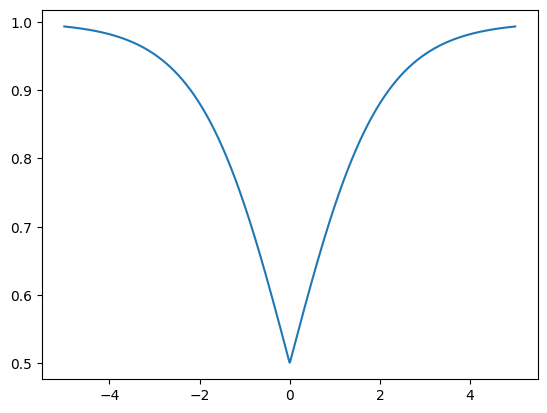

In [80]:
plt.plot(temp_x, temp_y)

In [81]:
i = 0

In [82]:
grid_dataset = ParameterGrid(
    {
        "train_size": [0.02],
        "n_features": np.arange(50, 401, 50),
        "n_splits": [5],
    }
)

grid_model = ParameterGrid(
    {"C_lasso": [0], "C_group": [2e-5, 2e-4, 2e-3], "C_ridge": [1e-5], "rank": [25]}
)

R_noisy: [-1.  1.]
R_full: [-1.  1.]
R_train: [0.  0.5 1. ]


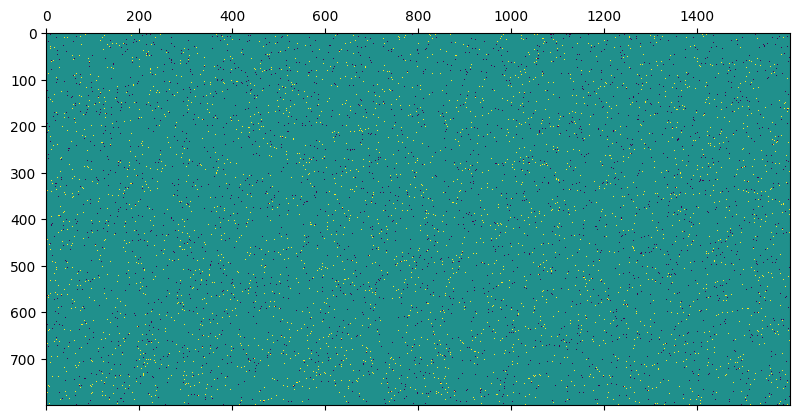

In [ ]:
i
par_dtst = grid_dataset[0]
X, Y, R_full, R_noisy = load(filename_input.format(i))
dvlp_size, test_size = 0.9, 0.1
ind_dvlp, ind_test = next(
    mc_split(
        R_full,
        n_splits=1,
        random_state=random_state,
        train_size=dvlp_size,
        test_size=test_size,
    )
)
R_test = get_submatrix(R_full, ind_test)
# prepare the train dataset: take the specified share from the beginnig of the index array
ind_train_all, _ = train_test_split(
    ind_dvlp,
    shuffle=False,
    random_state=random_state,
    test_size=(1 - (par_dtst["train_size"] / dvlp_size)),
)

R_train = get_submatrix(R_noisy, ind_train_all)
R_train = R_train.toarray()
R_train[R_train == 0] = 0.5
R_train[R_train == -1] = 0

plt.matshow(R_train)
print(f"R_noisy: {np.unique(R_noisy)}")
print(f"R_full: {np.unique(R_full)}")
print(f"R_train: {np.unique(R_train)}")

In [118]:
# set up the model
model = BiSSGL(
    Y=R_train,
    U=X,
    V=Y,
    xi=1,
    eta=0.0001,
    tilde_lambda0=1.5,
    tilde_lambda1=1,
    tilde_alpha=1 / 25,
    tilde_beta=1,
    lambda0=1.5,
    lambda1=1,
    alpha=1 / 25,
    beta=1,
    K=25,
    max_iter=1000,
    tol=1e-5,
)

# fit on the whole development dataset
est_mu, est_A, est_B, logLik = model.optimization()

Finished with iterations of 999


In [119]:
# R_full = (R_full > 0) * 1
# R_test = get_submatrix(R_full, ind_test)
np.unique(R_test.toarray())

array([-1.,  0.,  1.])

In [120]:
# get the score
prob_full = expit(X @ est_A @ est_B.T @ Y.T)
# prob_full = X @ est_A @ est_B.T @ Y.T
prob_test = get_submatrix(prob_full, ind_test)
scores_test = mc_get_scores(R_test, prob_test)
print("Test score:", scores_test)

Test score: {'tn': 58920, 'fn': 4960, 'fp': 5014, 'tp': 59106, 'auc': 0.9803601768674146}


In [98]:
def mc_get_scores(R_true, R_prob):
    R_pred = np.where(R_prob.data > 0.5, 1, 0)

    # compute the confusion matrix for ±1 labels (`-1` is negative)
    ii, jj = ((R_pred + 1) // 2).astype(int), ((R_true.data + 1) // 2).astype(int)
    cnfsn = confusion_matrix(y_true=jj, y_pred=ii)

    return {
        "tn": cnfsn[0, 0],
        "fn": cnfsn[1, 0],
        "fp": cnfsn[0, 1],
        "tp": cnfsn[1, 1],
        "auc": roc_auc_score(R_true.data, R_prob.data),
    }

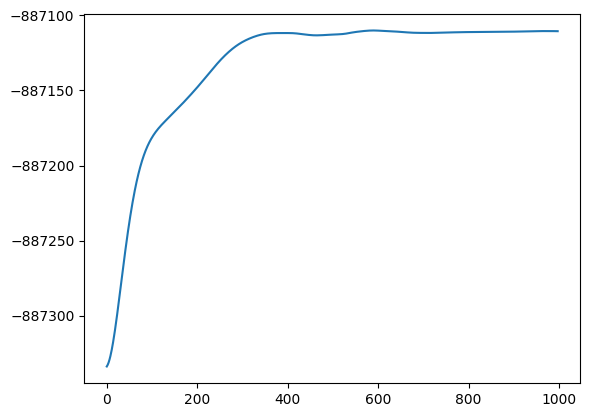

In [121]:
plt.plot(logLik)

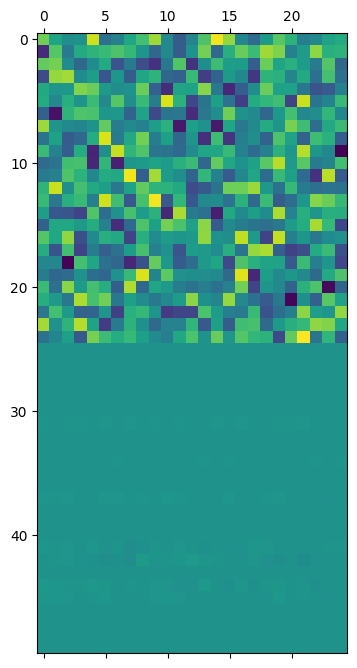

In [122]:
plt.matshow(est_A)

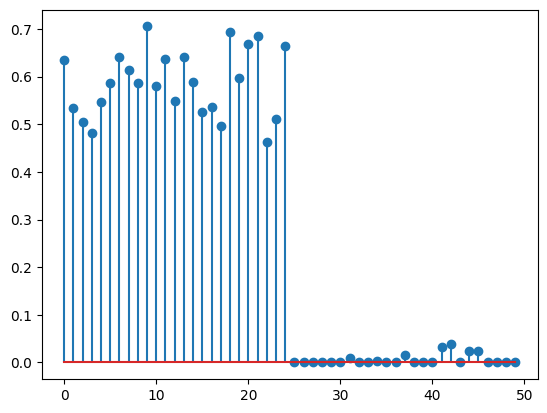

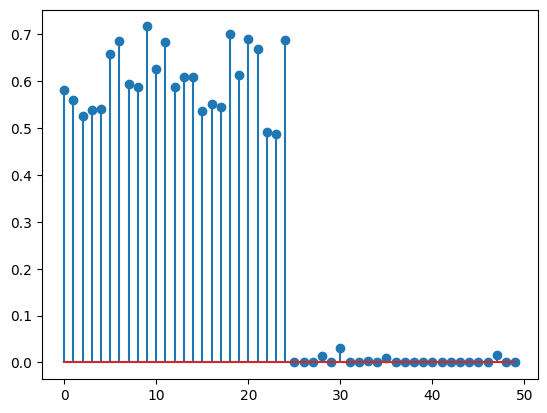

In [123]:
plt.stem(abs(est_A).max(axis=1))
plt.show()
plt.stem(abs(est_B).max(axis=1))
plt.show()

---

# Implement SGIMC 

In [143]:
from sgimc import SparseGroupIMCClassifier

In [102]:
grid_dataset = ParameterGrid(
    {
        "train_size": [0.02],
        "n_features": np.arange(50, 401, 50),
        "n_splits": [5],
    }
)

grid_model = ParameterGrid(
    {"C_lasso": [0.0], "C_group": [2e-5, 2e-4, 2e-3], "C_ridge": [1e-5], "rank": [25]}
)

par_mdl = grid_model[0]
par_dtst = grid_dataset[0]

In [144]:
i
X, Y, R_full, R_noisy = load(filename_input.format(i))
dvlp_size, test_size = 0.9, 0.1
ind_dvlp, ind_test = next(
    mc_split(
        R_full,
        n_splits=1,
        random_state=random_state,
        train_size=dvlp_size,
        test_size=test_size,
    )
)
R_test = get_submatrix(R_full, ind_test)
# prepare the train dataset: take the specified share from the beginnig of the index array
ind_train_all, _ = train_test_split(
    ind_dvlp,
    shuffle=False,
    random_state=random_state,
    test_size=(1 - (par_dtst["train_size"] / dvlp_size)),
)

print(f"R_noisy: {np.unique(R_noisy)}")
print(f"R_full: {np.unique(R_full)}")

R_noisy: [-1.  1.]
R_full: [-1.  1.]


Modify R_train to be mixed by -1 and 0 (missing)

R_train: [-1.  0.  1.]
R_train after replacement: [-1.  1.]


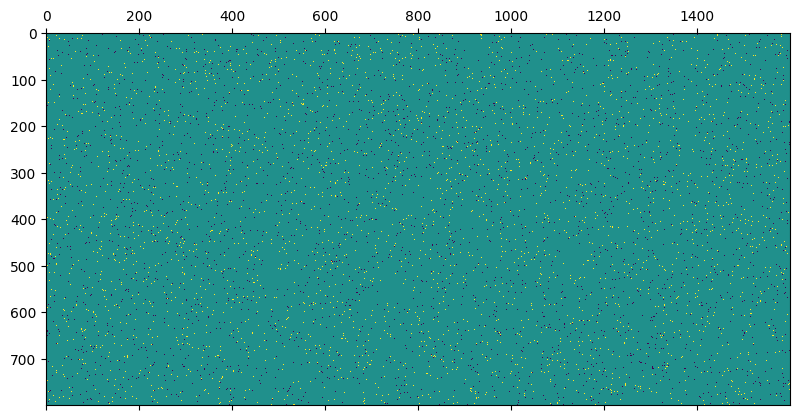

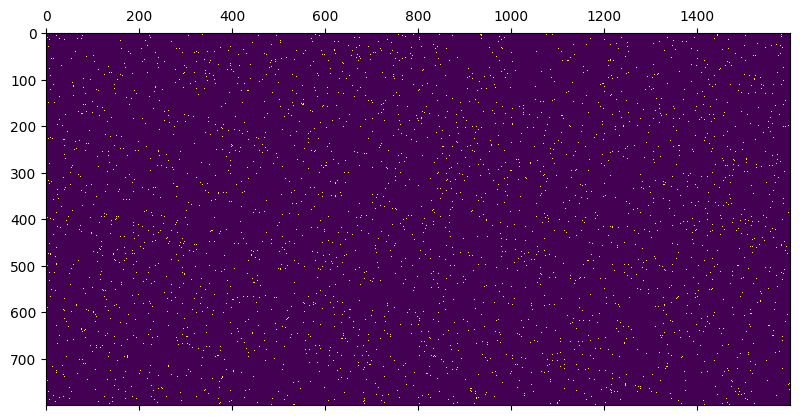

In [ ]:
# fit on the whole development dataset
R_train = get_submatrix(R_noisy, ind_train_all)
R_train = R_train.toarray()
plt.matshow(R_train)
print(f"R_train: {np.unique(R_train)}")

R_train[R_train == 0] = -1
plt.matshow(R_train)
print(f"R_train after replacement: {np.unique(R_train)}")
R_train = coo_matrix(R_train).tocsr()

In [146]:
C_lasso, C_group, C_ridge = par_mdl["C_lasso"], par_mdl["C_group"], par_mdl["C_ridge"]
imc = SparseGroupIMCClassifier(
    par_mdl["rank"],
    n_threads=8,
    random_state=42,
    C_lasso=C_lasso,
    C_group=C_group,
    C_ridge=C_ridge,
)

imc.fit(X, Y, R_train)

In [147]:
# prob_full = expit(imc.predict(X, Y))
prob_full = imc.predict_proba(X, Y)
prob_test = get_submatrix(prob_full, ind_test)
scores_test = mc_get_scores(R_test, prob_test)
print("Test score:", scores_test)

Test score: {'tn': 41955, 'fn': 23803, 'fp': 21858, 'tp': 40384, 'auc': 0.6556863392811519}


In [151]:
prob_full

array([[0.508164  , 0.50899929, 0.52511884, ..., 0.45929927, 0.5283772 ,
        0.51803635],
       [0.50830345, 0.52597235, 0.51380178, ..., 0.40783596, 0.56522632,
        0.52156931],
       [0.50633689, 0.49435488, 0.49895823, ..., 0.47636527, 0.51012098,
        0.52547187],
       ...,
       [0.49598046, 0.49466743, 0.49819707, ..., 0.52901777, 0.47842863,
        0.48677349],
       [0.50548626, 0.50164978, 0.49685765, ..., 0.46472327, 0.52866899,
        0.49234756],
       [0.51134248, 0.5043032 , 0.50306167, ..., 0.45720498, 0.53112564,
        0.52627155]])

<StemContainer object of 3 artists>

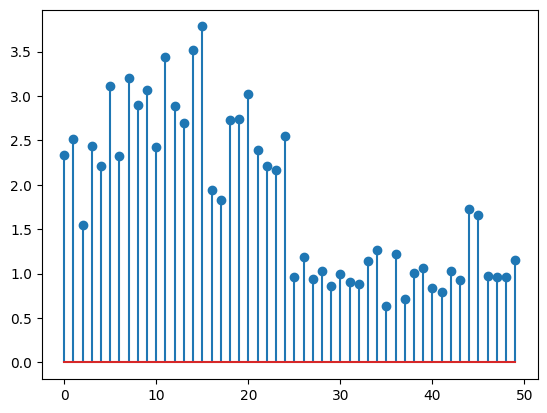

In [149]:
plt.stem(abs(imc.coef_H_).max(axis=1))

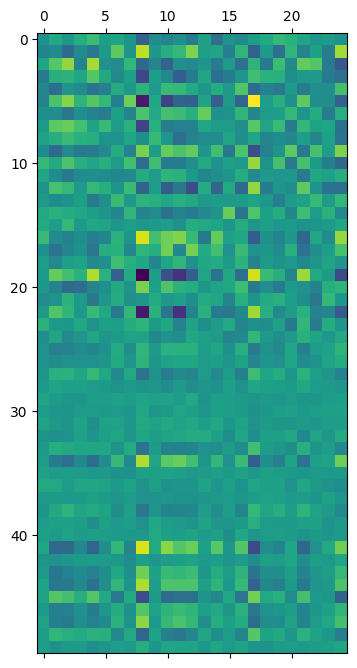

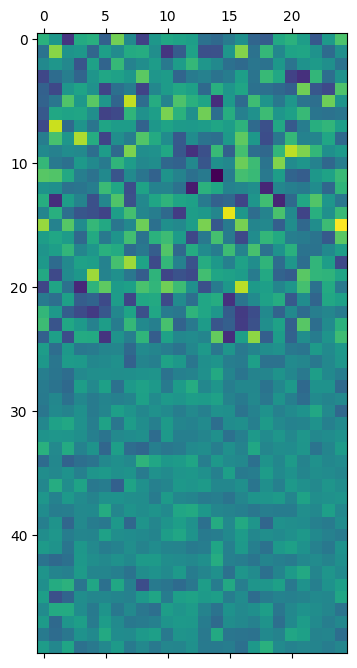

In [148]:
plt.matshow(imc.coef_W_)

plt.matshow(imc.coef_H_)

Simulation dimension: $800 \times 1600$ with $K = 25$.

\begin{array}{lrrr}
    \hline
    \text { Methods } & \text{ AUC (mixed with missing)} & \text{ AUC (missing specified) } & \text { K } & \\
    \hline
    \text { BiSSGL } & 0.980 & 0.631 &  25\\
    \text { SGIMC }  & 0.979 & 0.655 &  50\\
    \text { IMC }    &  &  &  -\\
    \hline
\end{array}